In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

try:
    sys.path.insert(0, str(Path('__file__').resolve().parents[1]))
except:
    sys.path.insert(0, str(Path.cwd().parent))
import shared

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import LineString
from shapely.strtree import STRtree

# Variables and paths
r_max_m = 50.0
target_chapel = "180"

gis_out_dir = shared.OUT / "vector_gis"
gis_out_dir.mkdir(exist_ok=True)

fig_out_dir = shared.OUT / "figures" / "fete"
fig_out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Load data
footprints, doors_data, doors_points, crosswalk = shared.get_base_preprocessed_data()
dem = shared.load_dem()
doors_points = shared.sample_dem_at_doors(doors_points)

hillshade = shared.hillshade(dem["disp"])
door_x_coords = [row.geometry.x for _, row in doors_points.iterrows()]
door_y_coords = [row.geometry.y for _, row in doors_points.iterrows()]

Loading DEM ...


  CRS=EPSG:32636  shape=(5138, 3902)  res=0.40 m  elev=65.2-145.0 m
Door elevation stats:
count    217.000000
mean     105.879623
std        9.303591
min       87.141602
25%       99.331055
50%      105.127930
75%      112.576172
max      125.653320


In [3]:
# Proximity graph
proximity_graph = nx.Graph()
for index, row in doors_points.iterrows():
    proximity_graph.add_node(
        index,
        x=row.geometry.x,
        y=row.geometry.y,
        chapel_id=row["chapel_id"],
        direction=row["direction"],
        is_door=True,
        elev=row["elevation_m"]
    )

building_tree = STRtree(footprints.geometry)

for i in range(len(doors_points)):
    point1 = doors_points.geometry.iloc[i]
    for j in range(i + 1, len(doors_points)):
        point2 = doors_points.geometry.iloc[j]
        distance = point1.distance(point2)
        if distance <= r_max_m:
            line = LineString([point1, point2])
            hits = building_tree.query(line)
            is_blocked = any(
                line.intersects(footprints.geometry.iloc[k]) and not line.touches(footprints.geometry.iloc[k]) 
                for k in hits
            )
            if not is_blocked:
                elev_diff = abs(doors_points.at[i, "elevation_m"] - doors_points.at[j, "elevation_m"])
                proximity_graph.add_edge(i, j, dist_m=distance, dh_m=elev_diff, weight=distance)

# FETE graph
fete_graph = nx.Graph()
for node, node_data in proximity_graph.nodes(data=True):
    fete_graph.add_node(node, **node_data)

for u, v, edge_data in proximity_graph.edges(data=True):
    distance = edge_data["dist_m"]
    elev_diff = edge_data["dh_m"]
    slope = elev_diff / distance if distance > 0 else 0
    speed_kmh = (6.0 * np.exp(-3.5 * abs(slope + 0.05)))
    speed_ms = speed_kmh / 3.6
    edge_weight = distance / speed_ms if speed_ms > 0 else distance / 0.1
    fete_graph.add_edge(u, v, dist_m=distance, dh_m=elev_diff, weight=edge_weight)

proximity_graph = fete_graph

In [4]:
# Edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(proximity_graph, weight="weight", normalized=True)
nx.set_edge_attributes(proximity_graph, edge_betweenness, "betweenness")
betweenness_values = np.array(list(edge_betweenness.values()))

path_lines = []
for (u, v), bc_val in edge_betweenness.items():
    node_u = proximity_graph.nodes[u]
    node_v = proximity_graph.nodes[v]
    line = LineString([(node_u["x"], node_u["y"]), (node_v["x"], node_v["y"])
    ])
    path_lines.append({
        "geometry": line,
        "betweenness": bc_val,
        "dist_m": proximity_graph[u][v]["dist_m"],
        "dh_m": proximity_graph[u][v]["dh_m"],
        "u_chapel": str(node_u.get("chapel_id") or ""),
        "v_chapel": str(node_v.get("chapel_id") or "")
    })
paths_data = gpd.GeoDataFrame(path_lines, geometry="geometry", crs=footprints.crs)

# Node statistics
node_betweenness = nx.betweenness_centrality(proximity_graph, weight="weight", normalized=True)
node_stats = []
for n in proximity_graph.nodes():
    if proximity_graph.nodes[n]["is_door"]:
        node_stats.append({
            "chapel_id": str(proximity_graph.nodes[n].get("chapel_id") or ""),
            "direction": str(proximity_graph.nodes[n].get("direction") or ""),
            "degree": proximity_graph.degree(n),
            "betweenness": node_betweenness[n],
            "elevation_m": proximity_graph.nodes[n].get("elev", np.nan)
        })
node_stats_df = pd.DataFrame(node_stats).sort_values("betweenness", ascending=False)

In [5]:
# Shortest paths
target_nodes = [n for n in proximity_graph.nodes() if str(proximity_graph.nodes[n].get("chapel_id")).split('.')[0] == target_chapel]
shortest_paths_data = None
if target_nodes:
    source_node = target_nodes[0]
    path_lengths = nx.single_source_dijkstra_path_length(proximity_graph, source_node, weight="weight")
    path_routes = nx.single_source_dijkstra_path(proximity_graph, source_node, weight="weight")
    reachable_doors = [n for n in proximity_graph.nodes() if proximity_graph.nodes[n].get("is_door") and n in path_lengths]
    drawn_edges = set()
    path_rows = []
    for dest in reachable_doors:
        route = path_routes[dest]
        for a, b in zip(route[:-1], route[1:]):
            edge_key = (min(a, b), max(a, b))
            if edge_key not in drawn_edges:
                drawn_edges.add(edge_key)
                node_a = proximity_graph.nodes[a]
                node_b = proximity_graph.nodes[b]
                line = LineString([(node_a["x"], node_a["y"]), (node_b["x"], node_b["y"])
                ])
                path_rows.append({
                    "geometry": line,
                    "path_cost": path_lengths.get(dest, np.nan)
                })
    shortest_paths_data = gpd.GeoDataFrame(path_rows, geometry="geometry", crs=footprints.crs)

  -> 10_proximity_graph.png


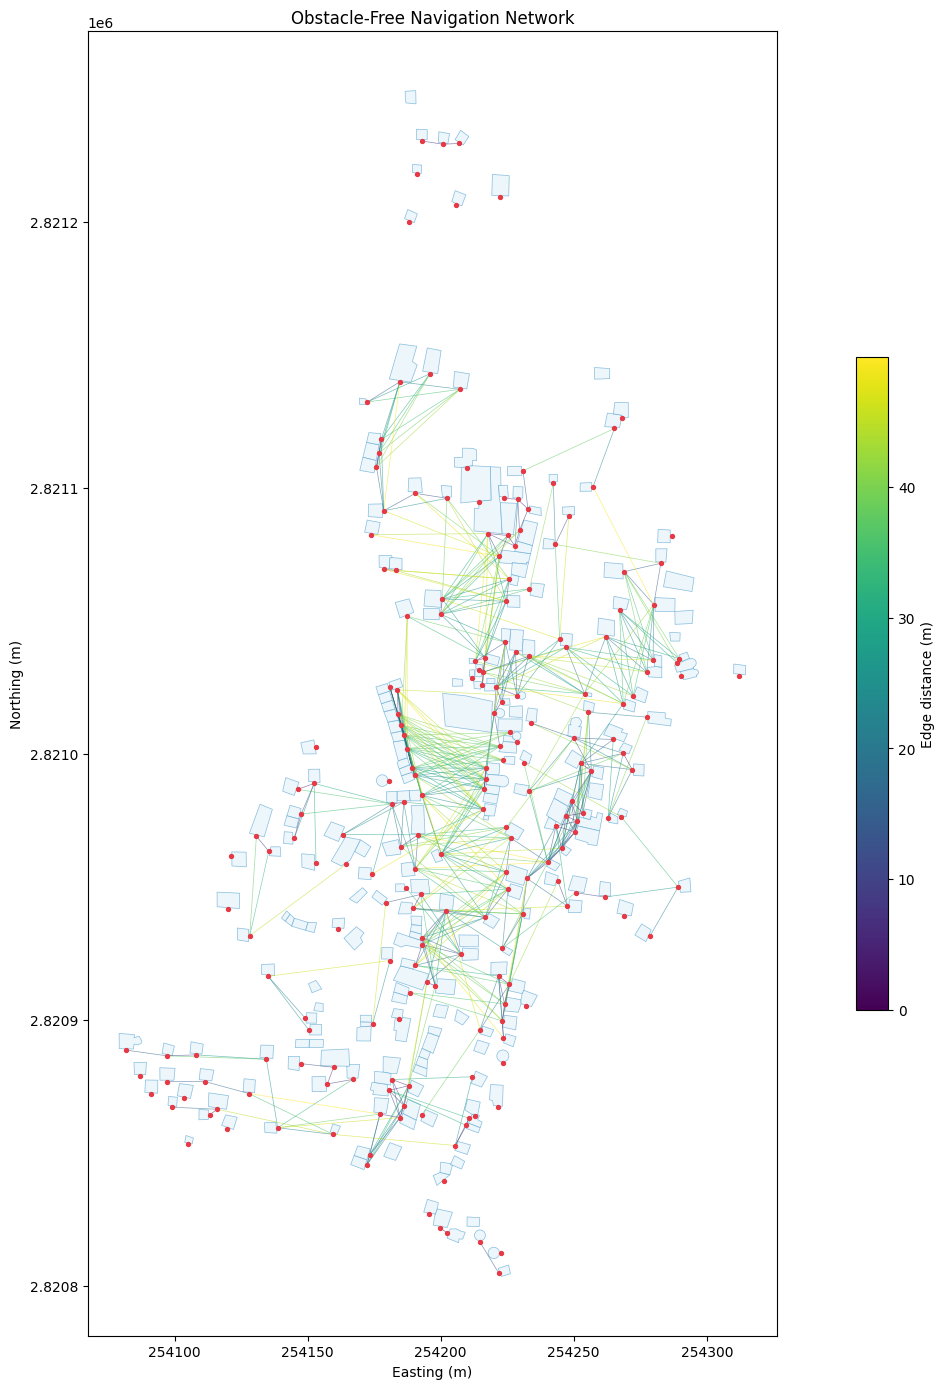

In [6]:
# Proximity graph plot
fig, ax = plt.subplots(figsize=(16, 14))
footprints.plot(ax=ax, color="#e8f4fb", edgecolor="#6baed6", linewidth=0.5, alpha=0.8)
max_dist = max(d["dist_m"] for _, _, d in proximity_graph.edges(data=True)) if proximity_graph.number_of_edges() else 1
dist_norm = mcolors.Normalize(vmin=0, vmax=max_dist)
for u, v, d in proximity_graph.edges(data=True):
    x_line = [proximity_graph.nodes[u]["x"], proximity_graph.nodes[v]["x"]]
    y_line = [proximity_graph.nodes[u]["y"], proximity_graph.nodes[v]["y"]]
    ax.plot(x_line, y_line, color=plt.cm.viridis(dist_norm(d["dist_m"])), linewidth=0.5, alpha=0.6)
ax.scatter(door_x_coords, door_y_coords, s=8, c="#e63946", zorder=5)
cbar_mappable = plt.cm.ScalarMappable(cmap="viridis", norm=dist_norm)
plt.colorbar(cbar_mappable, ax=ax, label="Edge distance (m)", shrink=0.5)
ax.set_title(f"Obstacle-Free Navigation Network")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
shared.save_fig(fig_out_dir, "10_proximity_graph.png")
plt.show()

  -> 11_path_network_betweenness.png


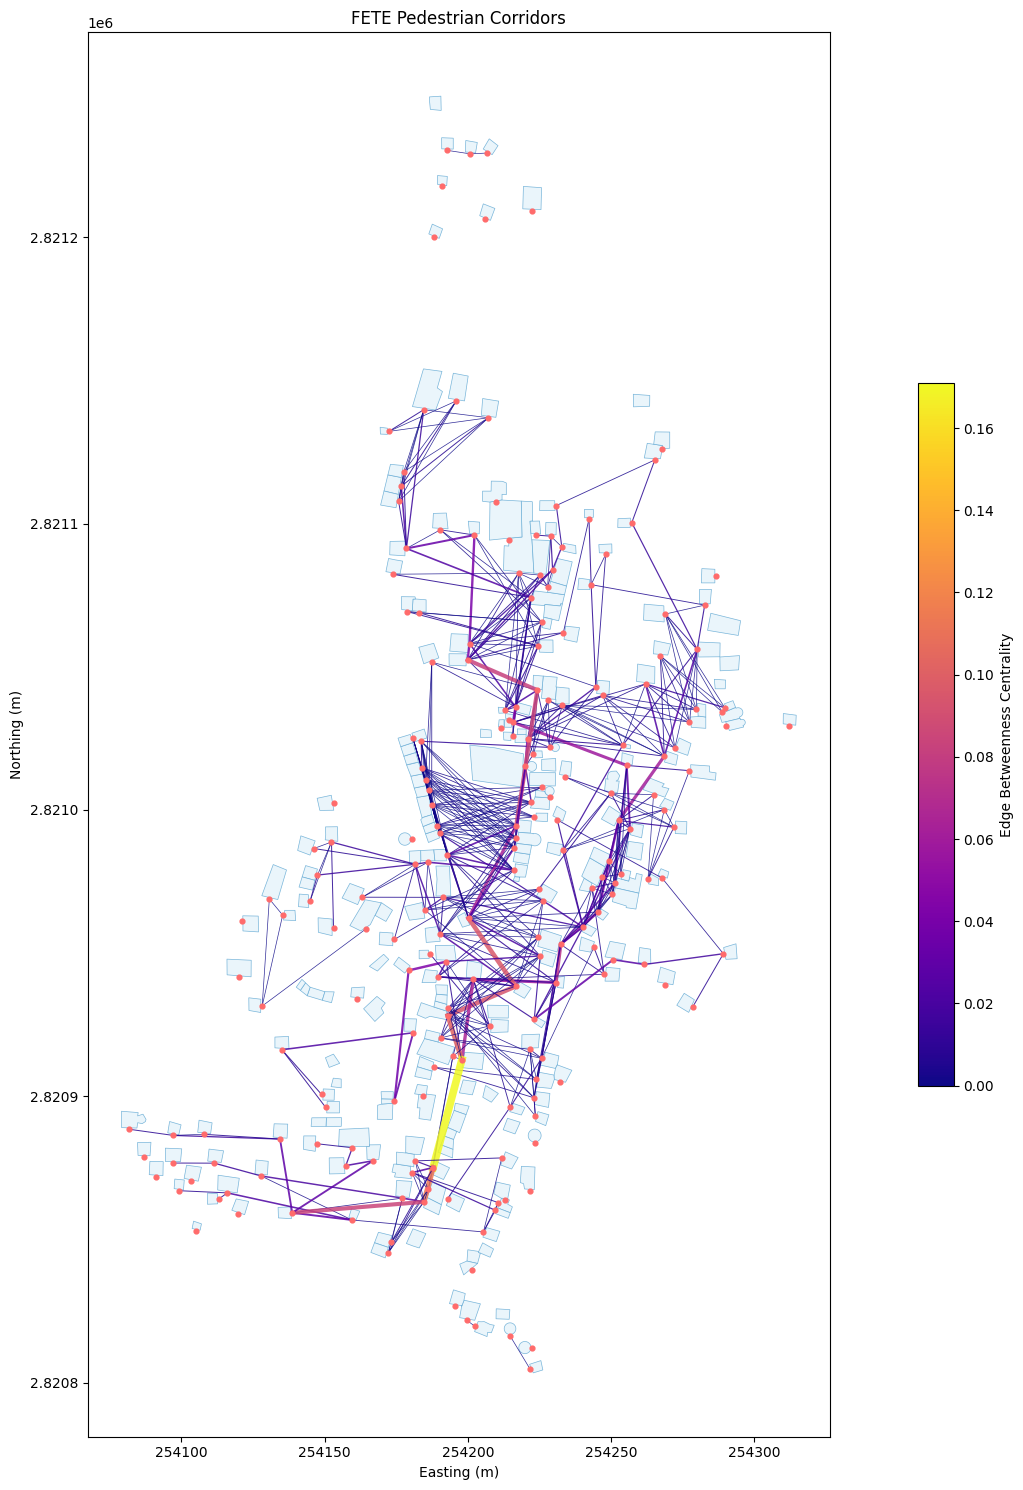

In [7]:
# Betweenness centrality plot
bc_cmap = plt.cm.plasma
bc_norm = mcolors.Normalize(vmin=0, vmax=max(betweenness_values.max(), 1e-9))
fig, ax = plt.subplots(figsize=(18, 15))
footprints.plot(ax=ax, color="#e8f4fb", edgecolor="#6baed6", linewidth=0.5, alpha=0.9)
for (u, v), bc_val in edge_betweenness.items():
    x_line = [proximity_graph.nodes[u]["x"], proximity_graph.nodes[v]["x"]]
    y_line = [proximity_graph.nodes[u]["y"], proximity_graph.nodes[v]["y"]]
    line_width = 0.5 + 5.0 * bc_val / max(betweenness_values.max(), 1e-9)
    ax.plot(x_line, y_line, color=bc_cmap(bc_norm(bc_val)), linewidth=line_width, alpha=0.85)
ax.scatter(door_x_coords, door_y_coords, s=12, c="#ff6b6b", zorder=6)
cbar_mappable2 = plt.cm.ScalarMappable(cmap=bc_cmap, norm=bc_norm)
plt.colorbar(cbar_mappable2, ax=ax, label="Edge Betweenness Centrality", shrink=0.5)
ax.set_title("FETE Pedestrian Corridors")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
shared.save_fig(fig_out_dir, "11_path_network_betweenness.png")
plt.show()

  -> 12_composite_full.png


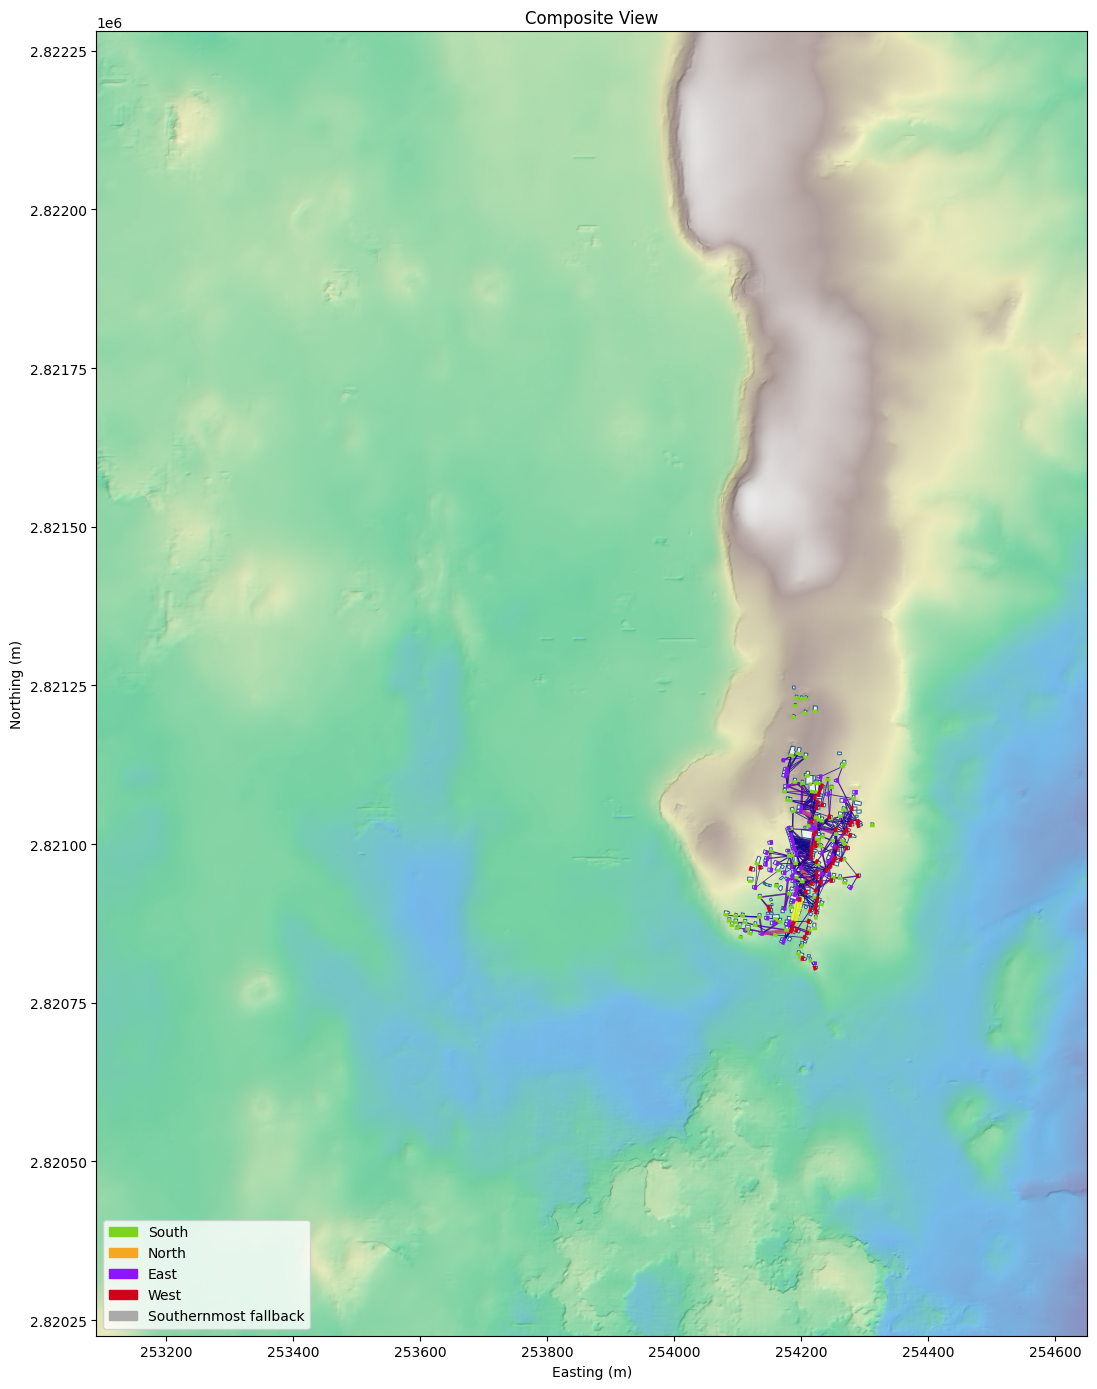

In [8]:
# Composite plot
fig, ax = plt.subplots(figsize=(18, 14))
ax.imshow(dem["disp"], extent=dem["extent"], origin="upper", cmap="terrain", alpha=0.65, vmin=dem["e_min"], vmax=dem["e_max"])
ax.imshow(hillshade, extent=dem["extent"], origin="upper", cmap="gray", alpha=0.3)
footprints.to_crs(dem["crs"]).plot(ax=ax, color="#f8fbfe", edgecolor="#08457e", linewidth=0.7, alpha=0.85)
for (u, v), bc_val in edge_betweenness.items():
    x_line = [proximity_graph.nodes[u]["x"], proximity_graph.nodes[v]["x"]]
    y_line = [proximity_graph.nodes[u]["y"], proximity_graph.nodes[v]["y"]]
    line_width = 0.5 + 5.0 * bc_val / max(betweenness_values.max(), 1e-9)
    ax.plot(x_line, y_line, color=bc_cmap(bc_norm(bc_val)), linewidth=line_width, alpha=0.85)
for _, row in doors_data.iterrows():
    x_coords, y_coords = row.geometry.xy
    ax.plot(x_coords, y_coords, color=shared.DIR_CLR.get(row["direction"], "#aaa"), linewidth=2.5, zorder=5)
ax.legend(handles=shared.direction_legend_patches(), loc="lower left", fontsize=10)
ax.set_title("Composite View")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
shared.save_fig(fig_out_dir, "12_composite_full.png")
plt.show()

  -> 16a_zoom_main_church_cluster.png


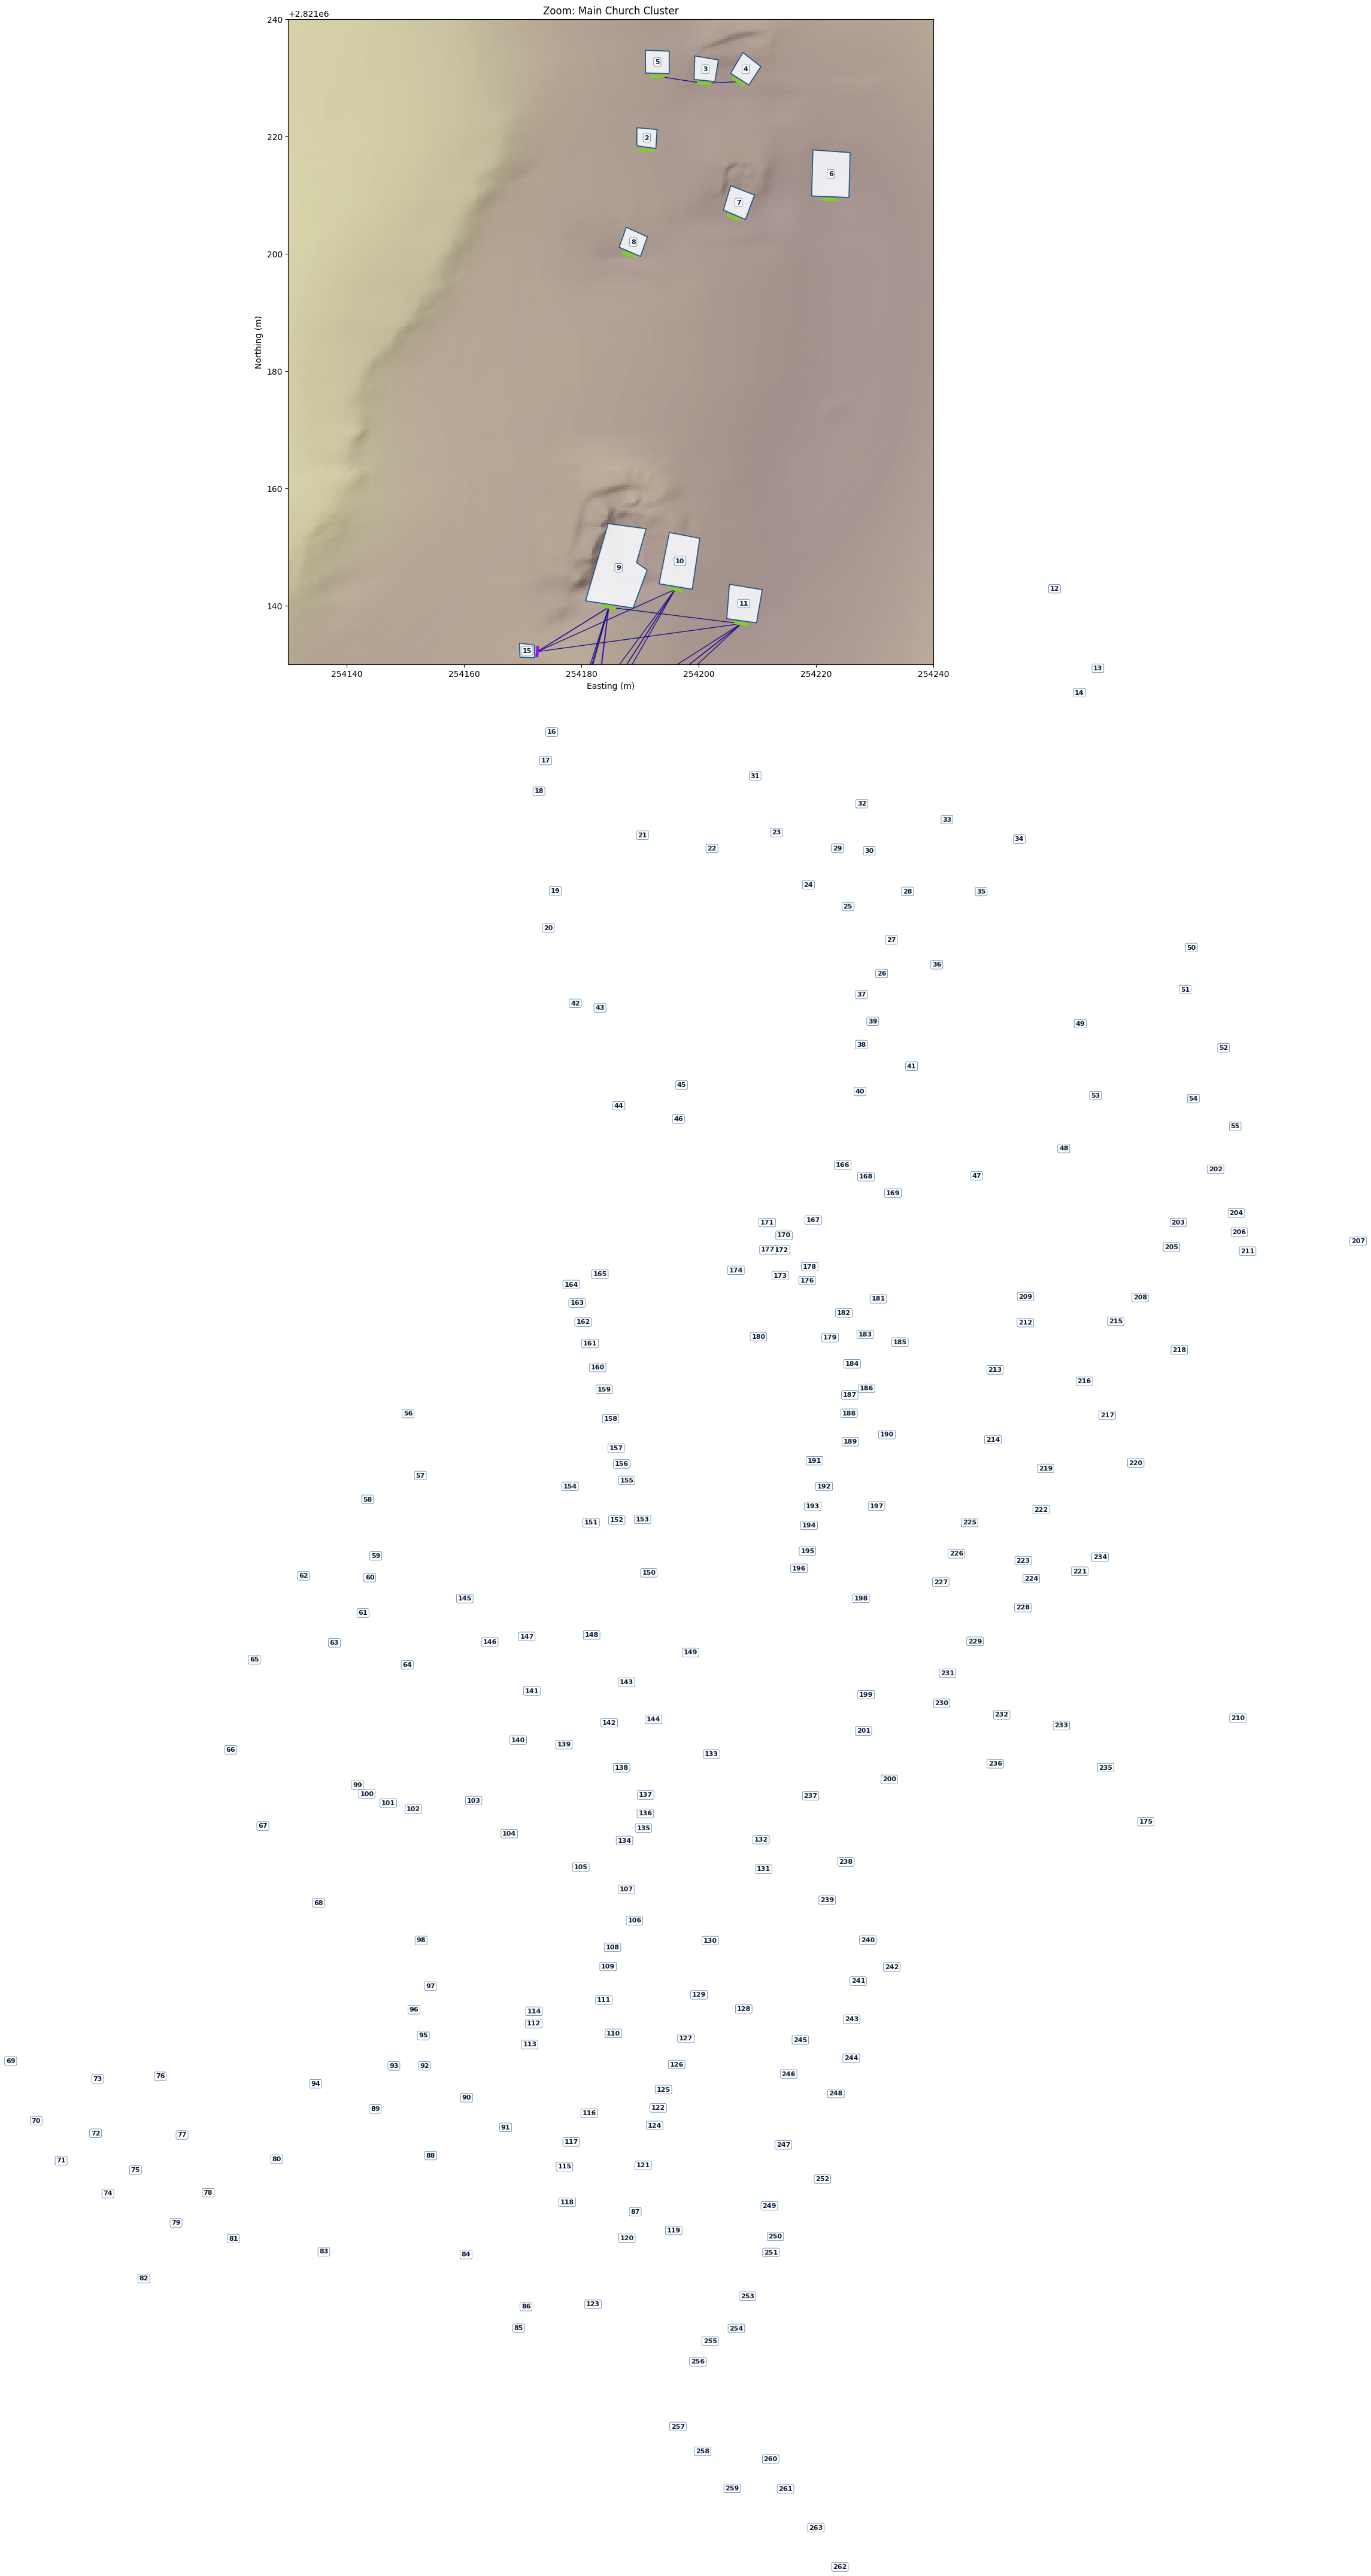

  -> 16b_zoom_north_necropolis.png


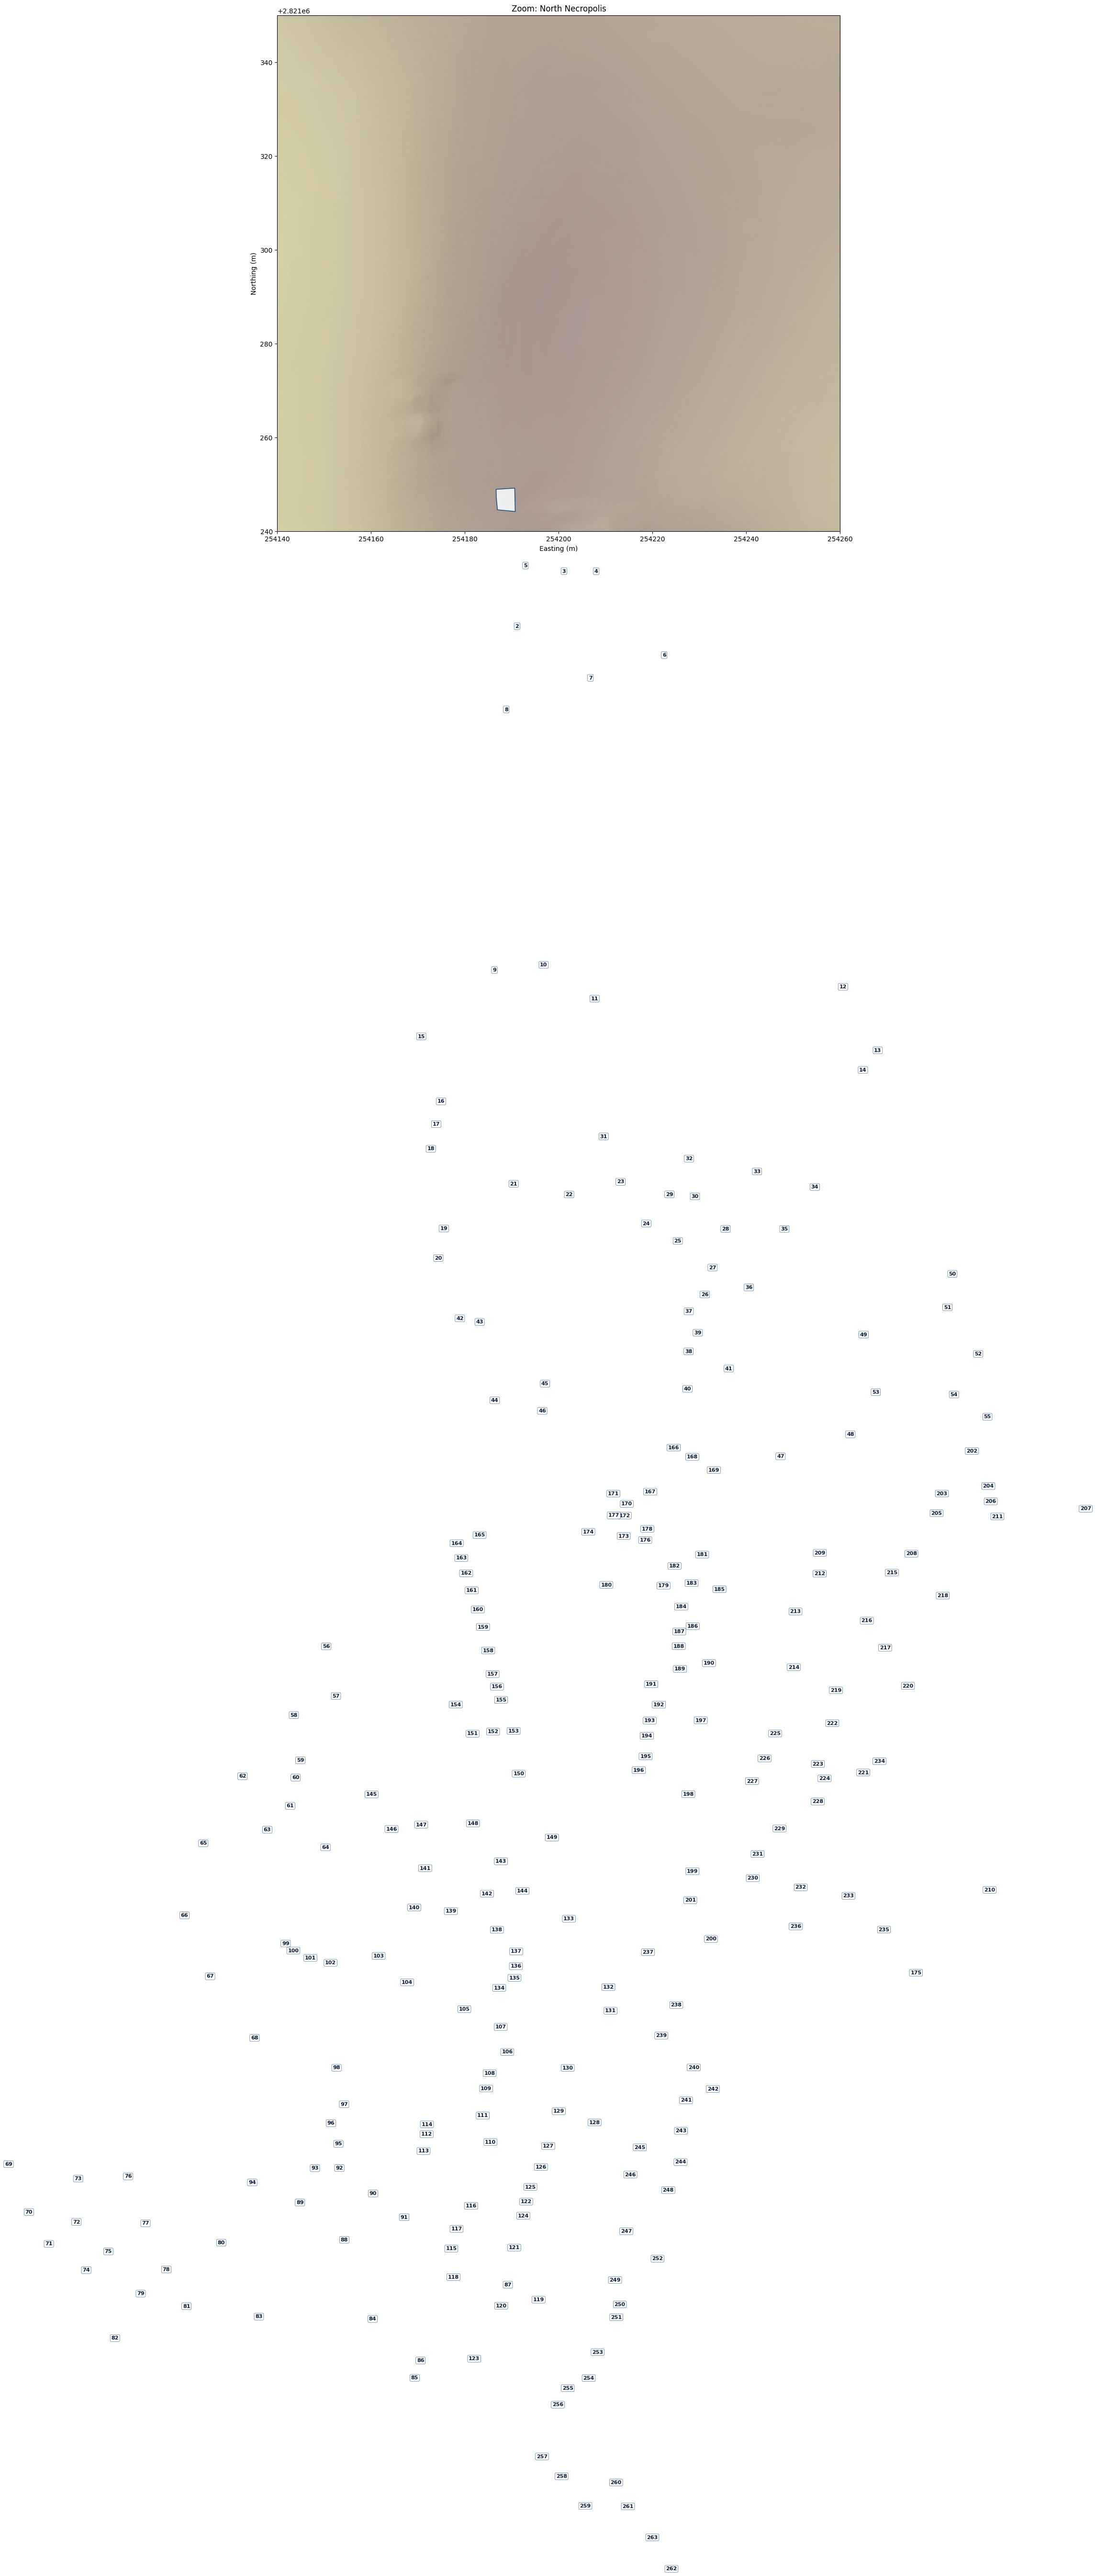

  -> 16c_zoom_central_corridors.png


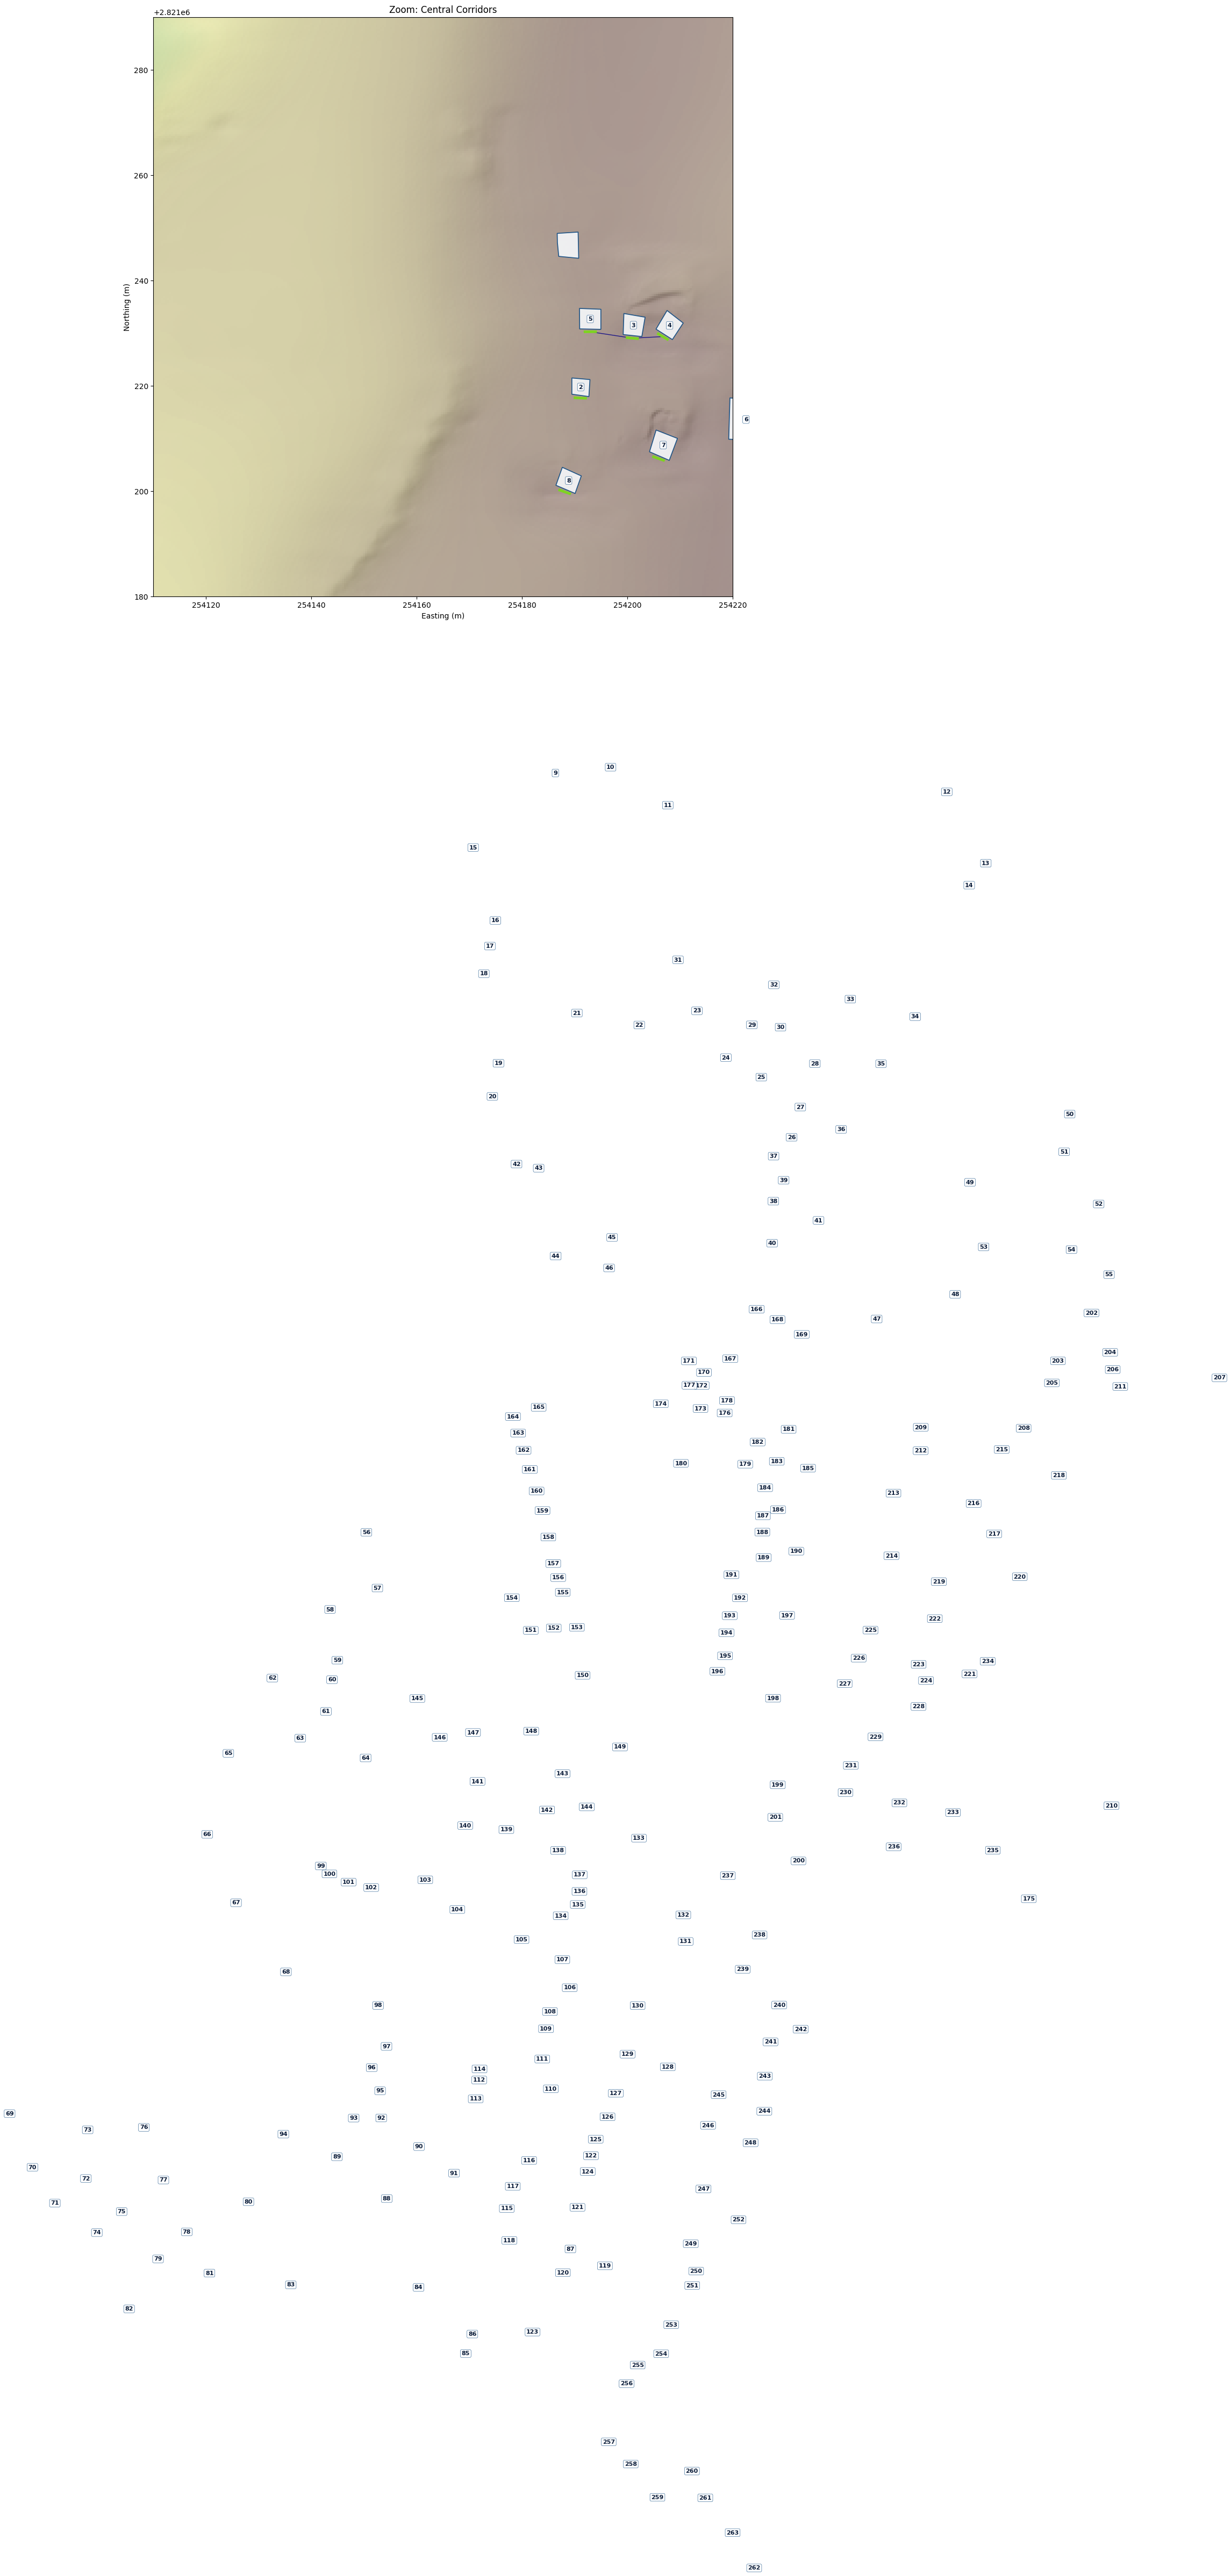

In [9]:
# Zoom plots
zoom_regions = [
    ("16a_zoom_main_church_cluster", [254130, 254240, 2821130, 2821240], "Main Church Cluster"),
    ("16b_zoom_north_necropolis", [254140, 254260, 2821240, 2821350], "North Necropolis"),
    ("16c_zoom_central_corridors", [254110, 254220, 2821180, 2821290], "Central Corridors")
]
for fname, (x_min, x_max, y_min, y_max), zoom_title in zoom_regions:
    fig, ax = plt.subplots(figsize=(16, 14))
    ax.imshow(dem["disp"], extent=dem["extent"], origin="upper", cmap="terrain", alpha=0.75, vmin=dem["e_min"], vmax=dem["e_max"])
    ax.imshow(hillshade, extent=dem["extent"], origin="upper", cmap="gray", alpha=0.30)
    footprints.to_crs(dem["crs"]).plot(ax=ax, color="#f8fbfe", edgecolor="#08457e", linewidth=1.2, alpha=0.88)
    for (u, v), bc_val in edge_betweenness.items():
        x_line = [proximity_graph.nodes[u]["x"], proximity_graph.nodes[v]["x"]]
        y_line = [proximity_graph.nodes[u]["y"], proximity_graph.nodes[v]["y"]]
        if not (min(x_line) > x_max or max(x_line) < x_min or min(y_line) > y_max or max(y_line) < y_min):
            line_width = 1.0 + 6.0 * bc_val / max(betweenness_values.max(), 1e-9)
            ax.plot(x_line, y_line, color=bc_cmap(bc_norm(bc_val)), linewidth=line_width, alpha=0.9)
    for _, row in doors_data.iterrows():
        x_coords, y_coords = row.geometry.xy
        if x_min <= x_coords[0] <= x_max and y_min <= y_coords[0] <= y_max:
            ax.plot(x_coords, y_coords, color=shared.DIR_CLR.get(row["direction"], "#aaa"), linewidth=3.5, zorder=5)
    shared._draw_chapel_ids(ax, footprints, fontsize=8, color="#0b1d3a", bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, ec="#08457e", lw=0.5))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Zoom: {zoom_title}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    shared.save_fig(fig_out_dir, f"{fname}.png", dpi=300)
    plt.show()

  -> 13_node_degree_betweenness.png


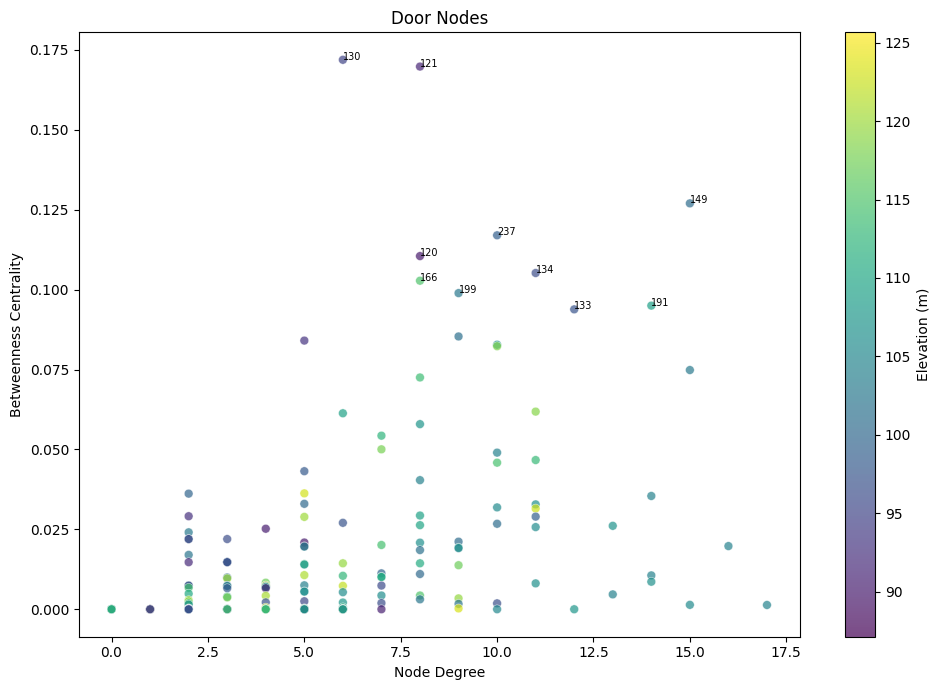

In [10]:
# Node degree vs betweenness plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter_plot = ax.scatter(node_stats_df["degree"], node_stats_df["betweenness"], c=node_stats_df["elevation_m"],
                          cmap="viridis", s=40, alpha=0.7, edgecolors="white", linewidths=0.4)
plt.colorbar(scatter_plot, ax=ax, label="Elevation (m)")
ax.set_xlabel("Node Degree")
ax.set_ylabel("Betweenness Centrality")
ax.set_title("Door Nodes")
for _, row in node_stats_df.head(10).iterrows():
    if row["chapel_id"] and row["chapel_id"] not in ("", "None"):
        ax.annotate(str(row["chapel_id"]), (row["degree"], row["betweenness"]), fontsize=7)
plt.tight_layout()
shared.save_fig(fig_out_dir, "13_node_degree_betweenness.png")
plt.show()

In [11]:
# Shortest paths plot
if shortest_paths_data is not None and not shortest_paths_data.empty:
    fig, ax = plt.subplots(figsize=(18, 15))
    footprints.plot(ax=ax, color="#e8f4fb", edgecolor="#6baed6", linewidth=0.7, alpha=0.9)
    shortest_paths_data.plot(ax=ax, color="#e63946", linewidth=1.5, alpha=0.8, label=f"Paths from Chapel {target_chapel}")
    source_x = proximity_graph.nodes[source_node]["x"]
    source_y = proximity_graph.nodes[source_node]["y"]
    ax.scatter([source_x], [source_y], s=200, c="gold", zorder=10, edgecolors="black", linewidths=1.5, label=f"Chapel {target_chapel}")
    shared._draw_chapel_ids(ax, footprints, fontsize=3.5, color="#111")
    ax.legend(loc="lower left", fontsize=10)
    ax.set_title(f"Shortest Paths from Chapel {target_chapel}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    shared.save_fig(fig_out_dir, f"14_shortest_paths_from_{target_chapel}.png")
    plt.show()

In [12]:
# Data export
paths_data.to_crs("EPSG:4326").to_file(str(gis_out_dir / "path_network_fete.geojson"), driver="GeoJSON")
paths_data.to_file(str(gis_out_dir / "path_network_fete.shp"))

export_footprints = footprints.copy()
for col in ["chapel_id", "direction", "raw_dir"]:
    export_footprints[col] = export_footprints[col].astype(str).replace({"None": "", "nan": ""})
export_footprints.to_crs("EPSG:4326").to_file(str(gis_out_dir / "footprints_attributed_fete.geojson"), driver="GeoJSON")
export_footprints.to_file(str(gis_out_dir / "footprints_attributed_fete.shp"))

doors_data.to_file(str(gis_out_dir / "doors_native_approach5_fete.shp"))
doors_points.to_file(str(gis_out_dir / "door_points_approach5_fete.shp"))

node_stats_df.to_csv(shared.OUT / "node_statistics_fete.csv", index=False)

if shortest_paths_data is not None and not shortest_paths_data.empty:
    shortest_paths_data.to_crs("EPSG:4326").to_file(str(gis_out_dir / f"shortest_paths_from_{target_chapel}_fete.geojson"), driver="GeoJSON")